# Power System Simulation
### From grid topology to practical grid decisions

In this project we built one package in three steps. First we analyse the grid structure, then we run
power flows over time, and finally we use both parts for EV, tap and N-1 studies.

## Our approach

| Assignment 1 | Assignment 2 | Assignment 3 |
|---|---|---|
| Understand the topology | Calculate behaviour over time | Make practical grid decisions |
| Downstream nodes and alternative lines | Voltage, loading and losses | EV impact, tap optimization and N-1 |

The main idea is that Assignment 3 reuses the topology from Assignment 1 and the time-series calculations
from Assignment 2.

In [1]:
import copy
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage, display
from PIL import Image
from power_grid_model import ComponentType, DatasetType, LoadGenType, WindingType, initialize_array

from power_system_simulation.ev_penetration import apply_ev_penetration
from power_system_simulation.graph_processing import GraphProcessor
from power_system_simulation.n_minus_one import calculate_n_minus_1
from power_system_simulation.pgm_processing import (
    aggregate_line_results,
    aggregate_node_voltage_results,
    create_load_batch_update,
    deserialize_pgm_json,
    read_json_file,
    read_load_profile,
    run_batch_power_flow,
)
from power_system_simulation.tap_optimization import optimize_tap_position
from power_system_simulation.time_series_analysis import run_time_series_power_flow

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

NAVY = "#17324D"
BLUE = "#2A6FBB"
LIGHT_BLUE = "#B9DDF2"
ORANGE = "#F28E55"
GREEN = "#31A785"
GREY = "#AAB6C2"
RED = "#D95D67"
PAPER = "#F6F8FB"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 4.8),
        "figure.facecolor": "white",
        "axes.facecolor": PAPER,
        "axes.edgecolor": "#D7DEE7",
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelcolor": NAVY,
        "text.color": NAVY,
        "font.size": 11,
        "grid.alpha": 0.35,
    }
)


def clean_axes(ax):
    ax.spines[["top", "right"]].set_visible(False)


print("Presentation setup ready")

Presentation setup ready


# 1. Understanding the grid topology

An LV grid normally operates as a tree, but it can contain disabled backup lines. We store every line in
one DataFrame row. This keeps the line ID, endpoints and status together.

In [2]:
edge_table = pd.DataFrame(
    {
        "edge_id": [4, 5, 8, 11, 24],
        "from_vertex": [3, 3, 6, 7, 9],
        "to_vertex": [6, 7, 9, 12, 12],
        "enabled": [True, True, True, True, False],
    }
)

graph = GraphProcessor(edge_table, source_vertex_id=3)
edge_table

,edge_id,from_vertex,to_vertex,enabled
0,4,3,6,True
1,5,3,7,True
2,8,6,9,True
3,11,7,12,True
4,24,9,12,False


### Finding the affected area and a backup line

If line **8** fails, node 9 becomes disconnected. The graph processor also finds that disabled line
**24** can reconnect this part without creating a cycle.

In [3]:
outage_line = 8
downstream_nodes = graph.find_downstream_vertices(outage_line)
alternative_lines = graph.find_alternative_edges(outage_line)

print("Downstream nodes:", downstream_nodes)
print("Possible alternative lines:", alternative_lines)

Downstream nodes: [9]
Possible alternative lines: [24]


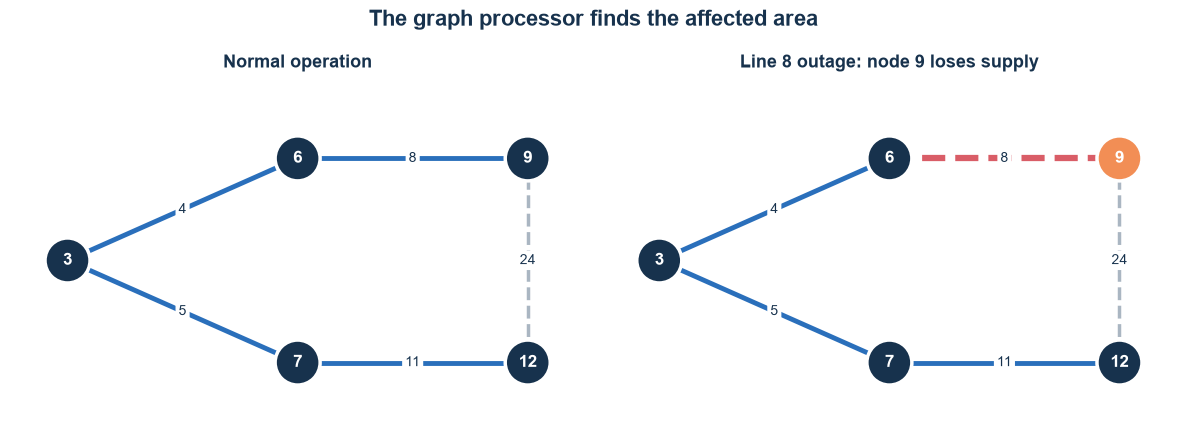

In [4]:
def draw_topology(ax, title, outage=None, connected_alternative=None, highlight_nodes=None):
    positions = {3: (0, 1), 6: (1, 1.5), 7: (1, 0.5), 9: (2, 1.5), 12: (2, 0.5)}
    grid_graph = nx.Graph()
    grid_graph.add_nodes_from(positions)
    for row in edge_table.itertuples():
        grid_graph.add_edge(row.from_vertex, row.to_vertex, edge_id=row.edge_id)

    ax.set_facecolor(PAPER)
    node_colors = [ORANGE if n in (highlight_nodes or []) else NAVY for n in grid_graph.nodes]
    nx.draw_networkx_nodes(
        grid_graph,
        positions,
        node_color=node_colors,
        edgecolors="white",
        linewidths=2.5,
        node_size=1050,
        ax=ax,
    )
    nx.draw_networkx_labels(grid_graph, positions, font_color="white", font_weight="bold", ax=ax)

    for row in edge_table.itertuples():
        color, style, width = BLUE, "solid", 3.5
        if not row.enabled:
            color, style, width = GREY, "dashed", 2.5
        if row.edge_id == outage:
            color, style, width = RED, "dashed", 4.5
        if row.edge_id == connected_alternative:
            color, style, width = GREEN, "solid", 5
        nx.draw_networkx_edges(
            grid_graph,
            positions,
            [(row.from_vertex, row.to_vertex)],
            edge_color=color,
            style=style,
            width=width,
            ax=ax,
        )
        midpoint = (
            (positions[row.from_vertex][0] + positions[row.to_vertex][0]) / 2,
            (positions[row.from_vertex][1] + positions[row.to_vertex][1]) / 2,
        )
        ax.text(
            *midpoint,
            str(row.edge_id),
            ha="center",
            va="center",
            fontsize=10,
            bbox={"boxstyle": "round,pad=0.22", "facecolor": "white", "edgecolor": "none"},
        )
    ax.set_title(title, pad=14)
    ax.set_xlim(-0.25, 2.25)
    ax.set_ylim(0.15, 1.85)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
draw_topology(axes[0], "Normal operation")
draw_topology(axes[1], "Line 8 outage: node 9 loses supply", outage=8, highlight_nodes=downstream_nodes)
fig.suptitle("The graph processor finds the affected area", fontsize=16, fontweight="bold", color=NAVY)
plt.tight_layout()

# 2. Time-series power flow

A single power flow is only one snapshot. Assignment 2 runs the complete load profile in one batch and
summarises the voltages, line loading and energy losses.

In [5]:
grid_data = deserialize_pgm_json(read_json_file(ROOT / "data" / "input_network_data.json"))
load_p = read_load_profile(ROOT / "data" / "active_power_profile.parquet")
load_q = read_load_profile(ROOT / "data" / "reactive_power_profile.parquet")

batch_update = create_load_batch_update(load_p, load_q)
results = run_batch_power_flow(grid_data, batch_update)
voltage_table = aggregate_node_voltage_results(results, load_p.index)
line_table = aggregate_line_results(results, load_p.index)

display(voltage_table.head(3).round(5))
display(line_table.round(4))

,max_u_pu,max_u_pu_node_id,min_u_pu,min_u_pu_node_id
timestamp,,,,
2024-01-01 00:00:00,1.00485,1,1.00345,3
2024-01-01 01:00:00,1.01205,3,1.00800,1
2024-01-01 02:00:00,0.99747,1,0.98437,4


C:\Users\20223081\AppData\Local\Temp\ipykernel_2812\3908661558.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(line_table.round(4))


,max_loading_pu,max_loading_timestamp,min_loading_pu,min_loading_timestamp,energy_loss_kwh
line_id,,,,,
5,0.1498,2024-01-01 06:00:00,0.0638,2024-01-01 03:00:00,63.2948
6,0.1110,2024-01-01 05:00:00,0.0372,2024-01-01 00:00:00,36.7751
7,0.0717,2024-01-01 02:00:00,0.0204,2024-01-01 01:00:00,14.8724


### What happens during the day?

The plots connect the input profiles to the calculated grid behaviour. The highest loaded line and the
total energy loss can be found directly from the aggregation tables.

Total energy loss: 114.9 kWh
Highest line loading: 0.150 p.u.


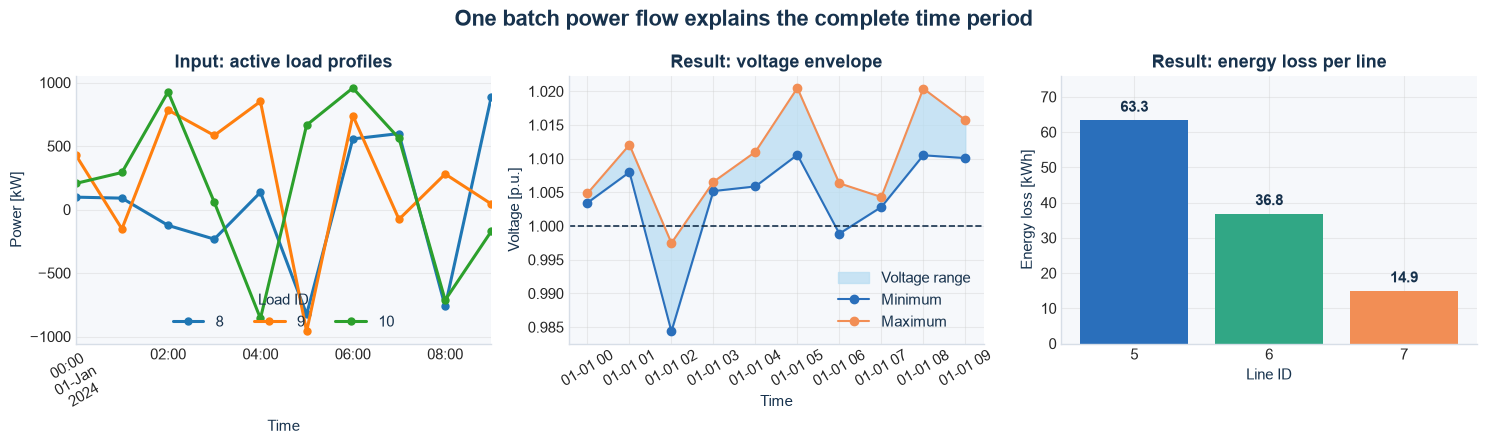

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

(load_p / 1000).plot(ax=axes[0], marker="o", linewidth=2.2, markersize=5)
axes[0].set(title="Input: active load profiles", ylabel="Power [kW]", xlabel="Time")
axes[0].legend(title="Load ID", frameon=False, ncol=3, loc="lower center")
clean_axes(axes[0])

axes[1].fill_between(
    voltage_table.index,
    voltage_table["min_u_pu"],
    voltage_table["max_u_pu"],
    color=LIGHT_BLUE,
    alpha=0.75,
    label="Voltage range",
)
axes[1].plot(voltage_table.index, voltage_table["min_u_pu"], color=BLUE, marker="o", label="Minimum")
axes[1].plot(voltage_table.index, voltage_table["max_u_pu"], color=ORANGE, marker="o", label="Maximum")
axes[1].axhline(1.0, color=NAVY, linewidth=1.2, linestyle="--")
axes[1].set(title="Result: voltage envelope", ylabel="Voltage [p.u.]", xlabel="Time")
axes[1].legend(frameon=False)
clean_axes(axes[1])

loss_bars = axes[2].bar(line_table.index.astype(str), line_table["energy_loss_kwh"], color=[BLUE, GREEN, ORANGE])
axes[2].bar_label(loss_bars, fmt="%.1f", padding=4, fontweight="bold")
axes[2].set(title="Result: energy loss per line", ylabel="Energy loss [kWh]", xlabel="Line ID")
axes[2].set_ylim(0, line_table["energy_loss_kwh"].max() * 1.2)
clean_axes(axes[2])

for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("One batch power flow explains the complete time period", fontsize=16, fontweight="bold")
plt.tight_layout()
print(f"Total energy loss: {line_table['energy_loss_kwh'].sum():.1f} kWh")
print(f"Highest line loading: {line_table['max_loading_pu'].max():.3f} p.u.")

### One important calculation

Line losses are power values at separate timestamps. We integrate these values using the trapezoidal rule
to obtain energy loss in kWh:

```python
hours = (time_index - time_index[0]).total_seconds() / 3600
energy_loss_kwh = np.trapezoid(loss_w, hours) / 1000
```

# 3. Practical grid studies

For Assignment 3 we combine topology and time-series calculations. The following ring grid is small
enough to clearly show every step, including its normally disabled backup line.

In [7]:
def create_demo_grid():
    nodes = initialize_array(DatasetType.input, ComponentType.node, 6)
    nodes["id"] = [1, 3, 6, 7, 9, 12]
    nodes["u_rated"] = [10500, 400, 400, 400, 400, 400]

    source = initialize_array(DatasetType.input, ComponentType.source, 1)
    source["id"], source["node"], source["status"] = 0, 1, 1
    source["u_ref"], source["sk"], source["rx_ratio"] = 1.0, 100e6, 0.1

    transformer = initialize_array(DatasetType.input, ComponentType.transformer, 1)
    transformer["id"], transformer["from_node"], transformer["to_node"] = 2, 1, 3
    transformer["from_status"], transformer["to_status"] = 1, 1
    transformer["u1"], transformer["u2"], transformer["sn"] = 10500, 400, 400e3
    transformer["uk"], transformer["pk"], transformer["i0"], transformer["p0"] = 0.04, 4000, 0, 0
    transformer["winding_from"], transformer["winding_to"], transformer["clock"] = (
        WindingType.delta,
        WindingType.wye_n,
        5,
    )
    transformer["tap_side"], transformer["tap_pos"], transformer["tap_min"] = 0, 0, -1
    transformer["tap_max"], transformer["tap_nom"], transformer["tap_size"] = 1, 0, 100

    lines = initialize_array(DatasetType.input, ComponentType.line, 5)
    lines["id"], lines["from_node"], lines["to_node"] = [4, 5, 8, 11, 24], [3, 3, 6, 7, 9], [6, 7, 9, 12, 12]
    lines["from_status"], lines["to_status"] = 1, [1, 1, 1, 1, 0]
    lines["r1"], lines["x1"], lines["c1"], lines["tan1"], lines["i_n"] = 0.05, 0.01, 0, 0, 200

    loads = initialize_array(DatasetType.input, ComponentType.sym_load, 2)
    loads["id"], loads["node"], loads["status"] = [10, 13], [9, 12], 1
    loads["type"], loads["p_specified"], loads["q_specified"] = LoadGenType.const_power, 0, 0
    return {
        ComponentType.node: nodes,
        ComponentType.source: source,
        ComponentType.transformer: transformer,
        ComponentType.line: lines,
        ComponentType.sym_load: loads,
    }


demo_grid = create_demo_grid()
demo_time = pd.date_range("2026-01-01", periods=3, freq="h")
demo_p = pd.DataFrame({10: [2000.0, 3000.0, 2500.0], 13: [2000.0, 2500.0, 3000.0]}, index=demo_time)
demo_q = pd.DataFrame({10: [500.0, 600.0, 550.0], 13: [500.0, 550.0, 600.0]}, index=demo_time)
ev_profiles = pd.DataFrame({"EV A": [0.0, 1000.0, 500.0], "EV B": [500.0, 0.0, 1000.0]}, index=demo_time)
print("Demo grid ready")

Demo grid ready


## 3A. EV penetration

EV profiles are assigned to houses per feeder. A fixed random seed makes the study reproducible.
The result is returned in the same format as Assignment 2, so it can be compared directly.

In [8]:
base_voltage, base_lines = run_time_series_power_flow(demo_grid, demo_p, demo_q)
ev_voltage, ev_lines = apply_ev_penetration(
    demo_grid,
    feeder_ids=[4, 5],
    load_p=demo_p,
    load_q=demo_q,
    ev_profiles=ev_profiles,
    penetration=1.0,
    seed=4,
)

comparison = pd.DataFrame(
    {
        "Base case": [
            base_voltage["min_u_pu"].min(),
            base_lines["max_loading_pu"].max(),
            base_lines["energy_loss_kwh"].sum(),
        ],
        "100% EV": [
            ev_voltage["min_u_pu"].min(),
            ev_lines["max_loading_pu"].max(),
            ev_lines["energy_loss_kwh"].sum(),
        ],
    },
    index=["Minimum voltage [p.u.]", "Maximum loading [p.u.]", "Energy loss [kWh]"],
)
comparison.round(5)

,Base case,100% EV
Minimum voltage [p.u.],0.99778,0.99743
Maximum loading [p.u.],0.02213,0.02569
Energy loss [kWh],0.01764,0.02504


Maximum line loading increases by 16.1%


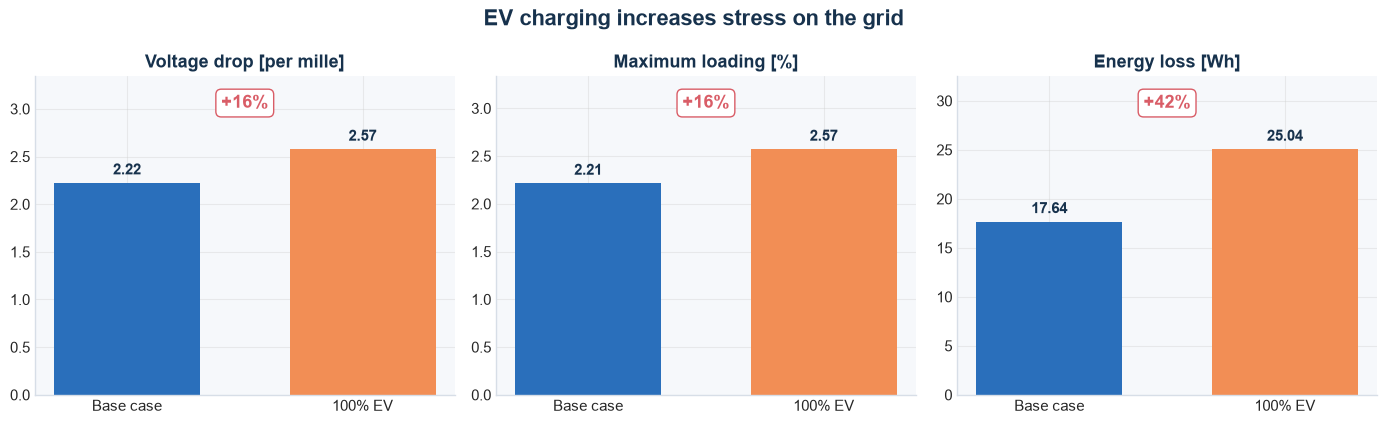

In [9]:
plot_comparison = pd.DataFrame(
    {
        "Base case": [
            (1 - comparison.loc["Minimum voltage [p.u.]", "Base case"]) * 1000,
            comparison.loc["Maximum loading [p.u.]", "Base case"] * 100,
            comparison.loc["Energy loss [kWh]", "Base case"] * 1000,
        ],
        "100% EV": [
            (1 - comparison.loc["Minimum voltage [p.u.]", "100% EV"]) * 1000,
            comparison.loc["Maximum loading [p.u.]", "100% EV"] * 100,
            comparison.loc["Energy loss [kWh]", "100% EV"] * 1000,
        ],
    },
    index=["Voltage drop [per mille]", "Maximum loading [%]", "Energy loss [Wh]"],
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, metric in zip(axes, plot_comparison.index, strict=True):
    values = plot_comparison.loc[metric]
    bars = ax.bar(values.index, values.values, color=[BLUE, ORANGE], width=0.62)
    ax.bar_label(bars, fmt="%.2f", padding=4, fontweight="bold")
    change = (values["100% EV"] / values["Base case"] - 1) * 100
    ax.text(
        0.5,
        0.90,
        f"+{change:.0f}%",
        transform=ax.transAxes,
        ha="center",
        color=RED,
        fontsize=13,
        fontweight="bold",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": RED},
    )
    ax.set_title(metric)
    ax.set_ylim(bottom=0, top=values.max() * 1.30)
    clean_axes(ax)

fig.suptitle("EV charging increases stress on the grid", fontsize=16, fontweight="bold")
plt.tight_layout()

increase = (
    comparison.loc["Maximum loading [p.u.]", "100% EV"] / comparison.loc["Maximum loading [p.u.]", "Base case"] - 1
) * 100
print(f"Maximum line loading increases by {increase:.1f}%")

## 3B. Optimal transformer tap

Every allowed tap position is tested over the full time period. The best tap depends on what we want to
improve: losses or voltage quality.

In [10]:
tap_rows = []
for tap in range(-1, 2):
    changed_grid = copy.deepcopy(demo_grid)
    changed_grid[ComponentType.transformer]["tap_pos"][0] = tap
    tap_results = run_batch_power_flow(changed_grid, create_load_batch_update(demo_p, demo_q))
    tap_lines = aggregate_line_results(tap_results, demo_p.index)
    node_voltages = tap_results[ComponentType.node]["u_pu"]
    tap_rows.append(
        {
            "tap": tap,
            "loss_kwh": tap_lines["energy_loss_kwh"].sum(),
            "voltage_criterion": np.mean(np.abs(node_voltages - 1)),
        }
    )

tap_sweep = pd.DataFrame(tap_rows).set_index("tap")
best_loss_tap = optimize_tap_position(demo_grid, demo_p, demo_q, criterion="loss")
best_voltage_tap = optimize_tap_position(demo_grid, demo_p, demo_q, criterion="voltage")
tap_sweep.round(6)

,loss_kwh,voltage_criterion
tap,,
-1,0.017309,0.007001
0,0.017645,0.001027
1,0.017984,0.008898


Best tap for minimum losses: -1
Best tap for voltage quality: 0


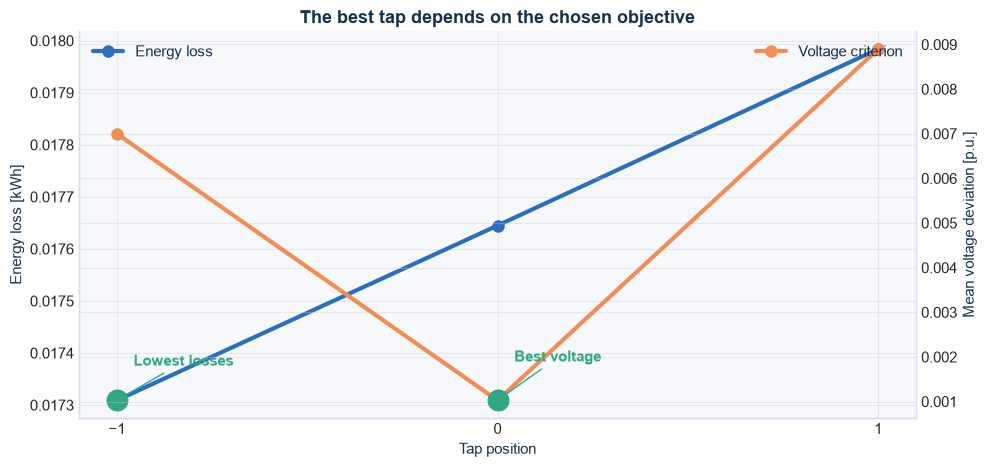

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax2 = ax1.twinx()

ax1.plot(
    tap_sweep.index,
    tap_sweep["loss_kwh"],
    color=BLUE,
    marker="o",
    markersize=8,
    linewidth=3,
    label="Energy loss",
)
ax2.plot(
    tap_sweep.index,
    tap_sweep["voltage_criterion"],
    color=ORANGE,
    marker="o",
    markersize=8,
    linewidth=3,
    label="Voltage criterion",
)
ax1.scatter(best_loss_tap, tap_sweep.loc[best_loss_tap, "loss_kwh"], color=GREEN, s=220, zorder=5)
ax2.scatter(best_voltage_tap, tap_sweep.loc[best_voltage_tap, "voltage_criterion"], color=GREEN, s=220, zorder=5)
ax1.annotate(
    "Lowest losses",
    (best_loss_tap, tap_sweep.loc[best_loss_tap, "loss_kwh"]),
    xytext=(12, 25),
    textcoords="offset points",
    color=GREEN,
    fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": GREEN},
)
ax2.annotate(
    "Best voltage",
    (best_voltage_tap, tap_sweep.loc[best_voltage_tap, "voltage_criterion"]),
    xytext=(12, 28),
    textcoords="offset points",
    color=GREEN,
    fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": GREEN},
)
ax1.set(title="The best tap depends on the chosen objective", xlabel="Tap position", ylabel="Energy loss [kWh]")
ax2.set_ylabel("Mean voltage deviation [p.u.]")
ax1.set_xticks(tap_sweep.index)
ax1.legend(loc="upper left", frameon=False)
ax2.legend(loc="upper right", frameon=False)
clean_axes(ax1)
ax2.spines["top"].set_visible(False)
plt.tight_layout()
print(f"Best tap for minimum losses: {best_loss_tap}")
print(f"Best tap for voltage quality: {best_voltage_tap}")

## 3C. N-1 analysis

For an outage, the topology analysis first finds possible backup lines. Each alternative is then tested
with a complete time-series power flow. The animation shows the same three steps used by the code.

In [12]:
n_minus_1_result = calculate_n_minus_1(demo_grid, demo_p, demo_q, outage_line_id=8)
n_minus_1_result.round(5)

C:\Users\20223081\AppData\Local\Temp\ipykernel_2812\347428980.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  n_minus_1_result.round(5)


,alternative_line_id,max_loading_pu,line_id,timestamp
0,24,0.04073,5,2026-01-01 01:00:00


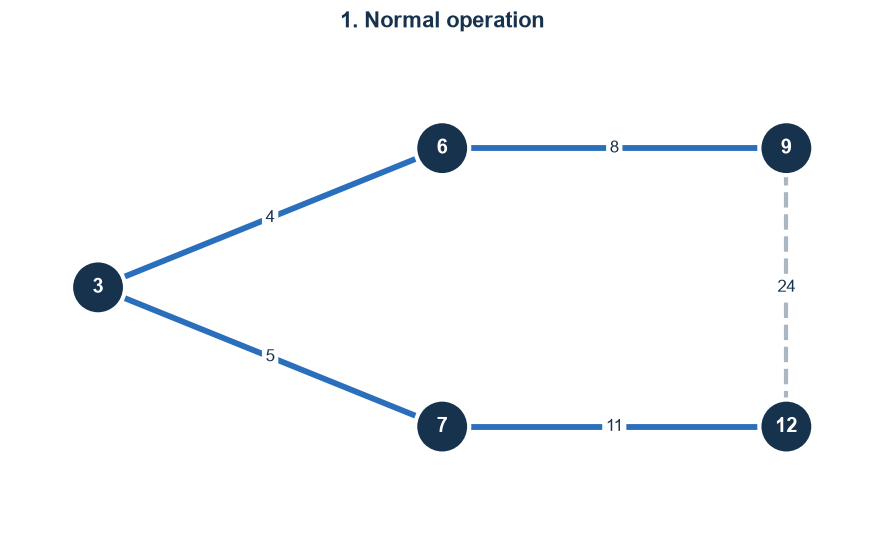

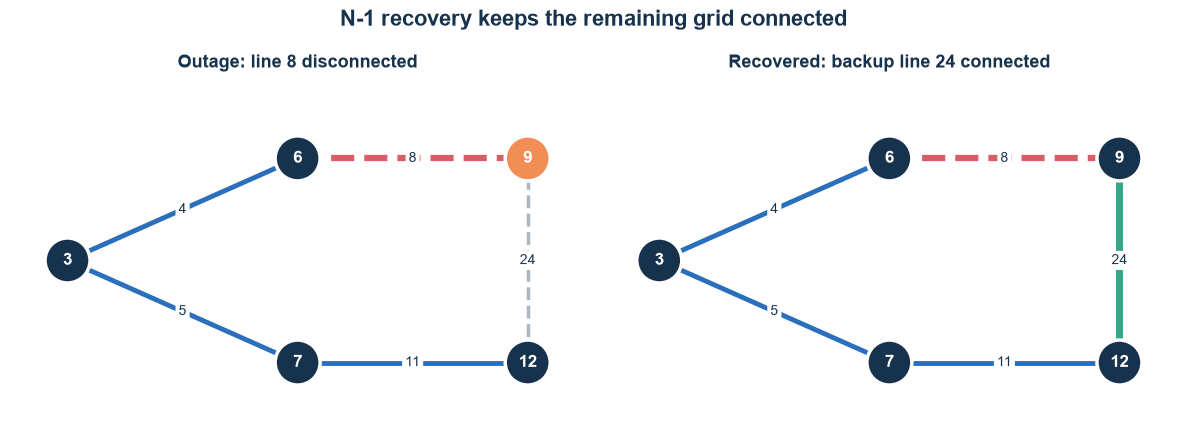

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
draw_topology(axes[0], "Outage: line 8 disconnected", outage=8, highlight_nodes=downstream_nodes)
draw_topology(axes[1], "Recovered: backup line 24 connected", outage=8, connected_alternative=24)
fig.suptitle("N-1 recovery keeps the remaining grid connected", fontsize=16, fontweight="bold")
plt.tight_layout()


def topology_frame(title, outage=None, alternative=None, highlighted=None):
    frame_figure, frame_axis = plt.subplots(figsize=(7.5, 4.6))
    draw_topology(
        frame_axis,
        title,
        outage=outage,
        connected_alternative=alternative,
        highlight_nodes=highlighted,
    )
    frame_figure.tight_layout()
    buffer = BytesIO()
    frame_figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    plt.close(frame_figure)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


frames = [
    topology_frame("1. Normal operation"),
    topology_frame("2. Line 8 outage: node 9 disconnected", outage=8, highlighted=downstream_nodes),
    topology_frame("3. Backup line 24 restores supply", outage=8, alternative=24),
]
gif_path = ROOT / "example" / "n_minus_1_recovery.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=[1100, 1400, 1800], loop=0)
display(NotebookImage(filename=str(gif_path)))

# Reliability and lessons learned

### Reliability
- Input data is validated before calculations start.
- Analysis functions use copies when they change grid settings.
- The complete local test suite passes with **100% code coverage**.
- Random EV assignment can be reproduced by using a seed.

### Collaboration
- We divided Assignment 3 into separate files and branches.
- Pull requests helped us review changes before merging them.
- Clear shared outputs from Assignments 1 and 2 made the final analyses easier to combine.
- Testing was especially useful for edge cases in tap optimization and N-1 calculations.

# Conclusion

The package does more than calculate one power flow:

1. It understands which parts of the grid are connected.
2. It shows voltage, loading and losses over time.
3. It uses these results to study EV charging, transformer taps and line outages.

The most important result is that the separate assignments now work together as one reusable workflow.